In [10]:
import pandas as pd
path = "/Users/thomasbenyazza/Downloads/Vincent_Lepinay/data_history.csv"

df = pd.read_csv(path, sep = ";")
display(df)


,Name,Title,biography,areas_of_interest,publications,University
0,Fredrik Albritton Jonsson,"Associate Professor of British History, Concep...","University of Chicago, PhD '05\n\nBIOGRAPHY\n\...",Britain|Early Modern Europe|Empires/Imperialis...,Monographs\n\nFredrik Albritton Jonsson and Ca...,Chicago
1,Clifford Ando,Robert O. Anderson Distinguished Service Profe...,"University of Michigan, PhD'96\n\nChair, Depar...",Ancient Mediterranean World|Cognition|Legal|Em...,News\n\nAppointed Extraordinary Professor in t...,Chicago
2,Leora Auslander,Arthur and Joann Rasmussen Professor in the De...,"Brown University, PhD '88\n\nBIOGRAPHY\n\nThe ...",Caribbean-Atlantic History|Cultural|Empires/Im...,Publications\n\nMy publications in the domain ...,Chicago
3,John W. Boyer,Martin A. Ryerson Distinguished Service Profes...,"University of Chicago, PhD '75\n\nBIOGRAPHY\n\...",Cultural|Empires/Imperialism|Modern Europe,Books and Essays on Central European History a...,Chicago
4,Mark Philip Bradley,Bernadotte E. Schmitt Distinguished Service Pr...,"Harvard University, PhD '95\n\nRESEARCH INTERE...",Cultural|East Asia|Human Rights|International|...,Books\n\nThe World Reimagined: Americans and H...,Chicago
...,...,...,...,...,...,...
482,Paula A. Sanders,Joseph and Joanna Nazro Mullen Professor Emeri...,"Research Areas Islamic history and culture, 7t...",Islamic history and culture|7th-15th centuries...,"Creating Medieval Cairo: Empire, Religion, and...",Rice
483,Richard J. Smith,George and Nancy Rupp Professor Emeritus of Hu...,Areas of Interest:Chinese history and cultureC...,NaN,NaN,Rice
484,Van Helden,"Professor Emeritus, History",Areas of Interest:History of AstronomyScientif...,NaN,The Invention of the Telescope . American Phil...,Rice
485,Wiener,Mary Gibbs Jones Professor Emeritus,Areas of Interest:Great Britain 1500- presentB...,NaN,English Culture and the Decline of the Industr...,Rice


In [11]:
print(df.columns)
print("==========================================================")
print(df["University"].unique())

Index(['Name', 'Title', 'biography', 'areas_of_interest', 'publications',
       'University'],
      dtype='object')
['Chicago' 'BYU' 'Harvard' 'Michigan' 'Stanford' 'Williams' 'Rice']


In [12]:
# On va garder que ublications, title, name, University
df = df[['publications', 'Title', 'Name', 'University']]
df = df.rename(columns={"publications": "Publications", "Title": "Title", "Name": "Name", "University": "University"})
print(df.columns)
display(df)
print("==========================================================")
print(len(df))

Index(['Publications', 'Title', 'Name', 'University'], dtype='object')


,Publications,Title,Name,University
0,Monographs\n\nFredrik Albritton Jonsson and Ca...,"Associate Professor of British History, Concep...",Fredrik Albritton Jonsson,Chicago
1,News\n\nAppointed Extraordinary Professor in t...,Robert O. Anderson Distinguished Service Profe...,Clifford Ando,Chicago
2,Publications\n\nMy publications in the domain ...,Arthur and Joann Rasmussen Professor in the De...,Leora Auslander,Chicago
3,Books and Essays on Central European History a...,Martin A. Ryerson Distinguished Service Profes...,John W. Boyer,Chicago
4,Books\n\nThe World Reimagined: Americans and H...,Bernadotte E. Schmitt Distinguished Service Pr...,Mark Philip Bradley,Chicago
...,...,...,...,...
482,"Creating Medieval Cairo: Empire, Religion, and...",Joseph and Joanna Nazro Mullen Professor Emeri...,Paula A. Sanders,Rice
483,NaN,George and Nancy Rupp Professor Emeritus of Hu...,Richard J. Smith,Rice
484,The Invention of the Telescope . American Phil...,"Professor Emeritus, History",Van Helden,Rice
485,English Culture and the Decline of the Industr...,Mary Gibbs Jones Professor Emeritus,Wiener,Rice


487


In [13]:
# On supprime si Publications est Nan ou vide
size_before = len(df)
df.dropna(subset=['Publications'], inplace=True)
display(df)
print("==========================================================")
size_now = len(df)
print(f"Nombre de lignes supprimées : {size_before - size_now}")
print(len(df))


,Publications,Title,Name,University
0,Monographs\n\nFredrik Albritton Jonsson and Ca...,"Associate Professor of British History, Concep...",Fredrik Albritton Jonsson,Chicago
1,News\n\nAppointed Extraordinary Professor in t...,Robert O. Anderson Distinguished Service Profe...,Clifford Ando,Chicago
2,Publications\n\nMy publications in the domain ...,Arthur and Joann Rasmussen Professor in the De...,Leora Auslander,Chicago
3,Books and Essays on Central European History a...,Martin A. Ryerson Distinguished Service Profes...,John W. Boyer,Chicago
4,Books\n\nThe World Reimagined: Americans and H...,Bernadotte E. Schmitt Distinguished Service Pr...,Mark Philip Bradley,Chicago
...,...,...,...,...
481,"“Carter, Reagan, and the End of the Cold War.”...",Professor Emeritus|Research Professor,Matusow,Rice
482,"Creating Medieval Cairo: Empire, Religion, and...",Joseph and Joanna Nazro Mullen Professor Emeri...,Paula A. Sanders,Rice
484,The Invention of the Telescope . American Phil...,"Professor Emeritus, History",Van Helden,Rice
485,English Culture and the Decline of the Industr...,Mary Gibbs Jones Professor Emeritus,Wiener,Rice


Nombre de lignes supprimées : 283
204


In [14]:
print(df['University'].unique())

['Chicago' 'BYU' 'Michigan' 'Stanford' 'Williams' 'Rice']


In [ ]:
import os
import pandas as pd
import requests

MODEL = "mistralai/mistral-7b-instruct-v0.3"
API = "http://localhost:1234/v1/chat/completions"

PROMPT_TEMPLATE = """Vous êtes un annotateur expert.
Analysez la liste de publications ci-dessous et déterminez si AU MOINS UNE concerne la France.
Répondez strictement par "Oui" ou "Non", sans aucun commentaire.

Publications :
{publications}
"""

# Fichiers
INPUT_PATH = "/Users/thomasbenyazza/Downloads/Vincent_Lepinay/data_history.csv"
ANNOT_PATH = "/Users/thomasbenyazza/Downloads/Vincent_Lepinay/data_history_annoted.csv"

# Charger DF ou reprendre DF annoté si déjà présent
if os.path.exists(ANNOT_PATH):
    df = pd.read_csv(ANNOT_PATH)
    print("Reprise du fichier annoté.")
else:
    df = pd.read_csv(INPUT_PATH, sep=";")
    df["Lien_France"] = ""   # colonne vide à remplir


def query_llm(prompt):
    headers = {"Content-Type": "application/json"}
    data = {
        "model": MODEL,
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": 200,
        "temperature": 0.0
    }

    response = requests.post(API, headers=headers, json=data)
    r = response.json()

    if "choices" not in r:
        return "Non"

    content = r["choices"][0]["message"]["content"].strip()

    if content.lower().startswith("oui"):
        return "Oui"
    else:
        return "Non"


# Boucle principale avec reprise automatique
for idx in df.index:
    # Si déjà annoté, on saute
    if df.loc[idx, "Lien_France"] in ["Oui", "Non"]:
        continue

    pubs = df.loc[idx, "publications"]
    prompt = PROMPT_TEMPLATE.format(publications=pubs)

    print(f"Processing row {idx+1}/{len(df)}")

    try:
        result = query_llm(prompt)
    except Exception as e:
        print("Erreur, arrêt :", e)
        break

    df.loc[idx, "Lien_France"] = result

    # Sauvegarde automatique à chaque itération
    df.to_csv(ANNOT_PATH, index=False)
    print(f"Response: {result}")

print("Annotation terminée.")


Processing row 1/487
Response: Oui
Processing row 2/487
Response: Oui
Processing row 3/487
Response: Oui
Processing row 4/487
Response: Non
Processing row 5/487
Response: Oui
Processing row 6/487
Response: Non
Processing row 7/487
Response: Oui
Processing row 8/487
Response: Non
Processing row 9/487
Response: Non
Processing row 10/487
Response: Oui
Processing row 11/487
Response: Non
Processing row 12/487
Response: Non
Processing row 13/487
Response: Non
Processing row 14/487
Response: Non
Processing row 15/487
Response: Oui
Processing row 16/487
Response: Oui
Processing row 17/487
Response: Oui
Processing row 18/487
Response: Non
Processing row 19/487
Response: Oui
Processing row 20/487
Response: Non
Processing row 21/487
Response: Non
Processing row 22/487
Response: Non
Processing row 23/487
Response: Non
Processing row 24/487
Response: Non
Processing row 25/487
Response: Oui
Processing row 26/487
Response: Oui
Processing row 27/487
Response: Non
Processing row 28/487
Response: Non
P

In [ ]:
data = pd.read_csv("/Users/thomasbenyazza/Downloads/Vincent_Lepinay/data_history_annoted.csv")
print(len(df)/len(data))

1.0


In [20]:
# On va conserver que "oui"

data = data[data["Lien_France"] == "Oui"]
display(data)
print(len(data))

,Name,Title,biography,areas_of_interest,publications,University,Lien_France
0,Fredrik Albritton Jonsson,"Associate Professor of British History, Concep...","University of Chicago, PhD '05\n\nBIOGRAPHY\n\...",Britain|Early Modern Europe|Empires/Imperialis...,Monographs\n\nFredrik Albritton Jonsson and Ca...,Chicago,Oui
1,Clifford Ando,Robert O. Anderson Distinguished Service Profe...,"University of Michigan, PhD'96\n\nChair, Depar...",Ancient Mediterranean World|Cognition|Legal|Em...,News\n\nAppointed Extraordinary Professor in t...,Chicago,Oui
2,Leora Auslander,Arthur and Joann Rasmussen Professor in the De...,"Brown University, PhD '88\n\nBIOGRAPHY\n\nThe ...",Caribbean-Atlantic History|Cultural|Empires/Im...,Publications\n\nMy publications in the domain ...,Chicago,Oui
4,Mark Philip Bradley,Bernadotte E. Schmitt Distinguished Service Pr...,"Harvard University, PhD '95\n\nRESEARCH INTERE...",Cultural|East Asia|Human Rights|International|...,Books\n\nThe World Reimagined: Americans and H...,Chicago,Oui
6,Susan L. Burns,"Professor of History, East Asian Languages and...","University of Chicago, PhD '94\n\nBIOGRAPHY\n\...",Cultural|East Asia|Gender and Sexuality|Intell...,Books\n\nKingdom of the Sick: A History of Lep...,Chicago,Oui
...,...,...,...,...,...,...,...
464,Osei-Opare,"Assistant Professor, Department of History|Aff...","Nana Osei-Opare is a historian of African, int...",African History|International History|historic...,Socialist De-Colony: Black and Entanglements i...,Rice,Oui
469,Maya Soifer Irish,Associate Professor of History|Affiliated Facu...,Dr. Maya Soifer Irish’s research focuses on re...,Medieval Europe|Medieval Iberia|Mediterranean ...,"""Jews and Christians in Medieval Castile: Trad...",Rice,Oui
470,Suarez-Potts,Associate Professor,Dr. Suárez-Potts is a legal historian. His fir...,Legal History|and Latin American and Mexican H...,"“The Ambiguity of Labor Justice in Mexico, 190...",Rice,Oui
476,Sidney Lu,Annette and Hugh Gragg Associate Professor of ...,Sidney Lu is a social and cultural historian o...,NaN,Collaborative Settler Colonialism: Japanese Mi...,Rice,Oui


87


In [25]:
print(data["University"].unique())
print(df["University"].unique())



['Chicago' 'BYU' 'Michigan' 'Stanford' 'Williams' 'Rice']
['Chicago' 'BYU' 'Harvard' 'Michigan' 'Stanford' 'Williams' 'Rice']


Intéressant, harvard ne semble pas parler de la France...

In [30]:
PROMPT_SUBJECT = """Vous êtes un expert en analyse de texte.
Votre tâche est d'extraire le sujet principal des publications listées ci-dessous.

Répondez par un unique sujet clair et résumé en moins de 5 mots maximum.
Ne faites pas de phrase longue et ne commentez rien.

Publications :
{publications}

Répondez uniquement par le sujet :
"""

FILE = "/Users/thomasbenyazza/Downloads/Vincent_Lepinay/data_history_annoted.csv"


data["Sujet_France"] = data.get("Sujet_France", "")

PROMPT_SUBJECT = """Vous êtes un expert en analyse de texte.
Votre tâche est d'extraire le sujet principal des publications listées ci-dessous.

Répondez par un unique sujet clair et résumé en un, deux ou trois mots maximum.
Ne faites pas de phrase et ne commentez rien.

Publications :
{publications}

Répondez uniquement par le sujet :
"""

def call_llm(prompt):
    headers = {"Content-Type": "application/json"}
    data = {
        "model": MODEL,
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": 200,
        "temperature": 0.2
    }

    r = requests.post(API, headers=headers, json=data).json()
    if "choices" not in r:
        return "Inconnu"

    return r["choices"][0]["message"]["content"].strip()


for idx in data.index:
    if data.loc[idx, "Sujet_France"] not in ["", None]:
        continue

    pubs = data.loc[idx, "publications"]
    prompt = PROMPT_SUBJECT.format(publications=pubs)
    print(f"Annoting row {idx}")

    try:
        result = call_llm(prompt)
    except:
        result = "Inconnu"

    # on nettoie la réponse, toujours important
    result = result.replace("\n", " ").strip()

    data.loc[idx, "Sujet_France"] = result

    data.to_csv(FILE, index=False)
    print("Sujet:", result)

print("Terminé.")


Annoting row 4
Sujet: American history, human rights, Vietnam War, international relations, diplomacy
Annoting row 6
Sujet: History of Leprosy and Japan, Gender Studies, Medical History, East Asian Studies
Annoting row 9
Sujet: Histoire de la colonisation française, commerce et esclavage en Saint-Domingue (Haïti)
Annoting row 14
Sujet: Histoire du Brésil, Inégalité sociale, Urbanisation, Droits de l'homme, Politique, Gouvernance informelle
Annoting row 15
Sujet: Marian Studies, Moyen Age, Spiritualité chrétienne, Exégèse biblique, Litturgie médiévale
Annoting row 16
Sujet: Cultural Studies (Books)
Annoting row 18
Sujet: 1. Black Chicago History (1940-1955) 2. African American Activism (1850-1950) 3. Obama Oral History Research 4. 1919 Chicago Race Riots 5. University of Chicago Affiliation
Annoting row 24
Sujet: History & Information Science
Annoting row 25
Sujet: Slavery (Histoire de l'esclavage)
Annoting row 28
Sujet: 1. Time of Anarchy: Indigenous Power and the Crisis of Colonialism

In [33]:
print(data.columns)
display(data["Sujet_France"])
print(len(data["Sujet_France"].unique()))

Index(['Name', 'Title', 'biography', 'areas_of_interest', 'publications',
       'University', 'Lien_France', 'Sujet_France'],
      dtype='object')


0      1. Monographs: Scarcity, Green Victorians, Enl...
1                                  Académicien classique
2      * Material culture, histories of production an...
4      American history, human rights, Vietnam War, i...
6      History of Leprosy and Japan, Gender Studies, ...
                             ...                        
464    Ghana's Cold War, Postcolonial Africa, Soviet ...
469                  Medieval Castile - Jewish relations
470                                   Labour Law, Mexico
476    Japanese Settler Colonialism in Brazil, Trans-...
480    Late Antiquity History, Byzantine Empire, Eura...
Name: Sujet_France, Length: 87, dtype: object

87


In [55]:
# On va en faire un csv à part
path = "/Users/thomasbenyazza/Downloads/Vincent_Lepinay/sujets_history.csv"
sujets = pd.DataFrame(data["Sujet_France"])

sujets.to_csv(path, index=False, sep=";")


In [57]:
# Après requête CHATGGPT on a :
area = [
    [
        "colonialism", "empire", "slavery", "french colonialism",
        "african colonial history", "settler colonialism",
        "postcolonial studies", "indigenous history"
    ],
    [
        "atlantic history", "caribbean", "louisiana",
        "slave trade", "maritime trade", "diaspora"
    ],
    [
        "war", "geopolitics", "diplomacy", "international relations",
        "cold war", "vietnam war", "global conflict"
    ],
    [
        "environmental history", "anthropocene", "resources",
        "industry", "extraction", "climate change"
    ],
    [
        "economic history", "capitalism", "labor", "development",
        "industrialization", "political economy"
    ],
    [
        "political history", "state formation", "governance",
        "institutions", "citizenship", "revolution"
    ],
    [
        "modern france", "french intellectual history",
        "foucault", "modern french culture"
    ],
    [
        "jewish history", "holocaust", "antisemitism",
        "genocide", "middle east"
    ],
    [
        "religious history", "christianity", "islam",
        "judaism", "spirituality", "liturgical studies"
    ],
    [
        "gender studies", "race", "sexuality",
        "black studies", "civil rights"
    ],
    [
        "material culture", "everyday life",
        "social history", "cultural studies"
    ],
    [
        "mediterranean studies", "italian history",
        "fascism", "south europe"
    ],
    [
        "asian history", "china", "japan",
        "trans-pacific history", "asia empires"
    ],
    [
        "digital humanities", "archives", "history of information",
        "knowledge systems"
    ]
]


themes = [
    "colonialism & empire",
    "atlantic world",
    "wars & diplomacy",
    "environment",
    "capitalism",
    "politics",
    "intellectual history of france",
    "jewish history & holocaust",
    "religion",
    "gender & race",
    "material culture",
    "mediterranean",
    "asia",
    "digital humanities"
]


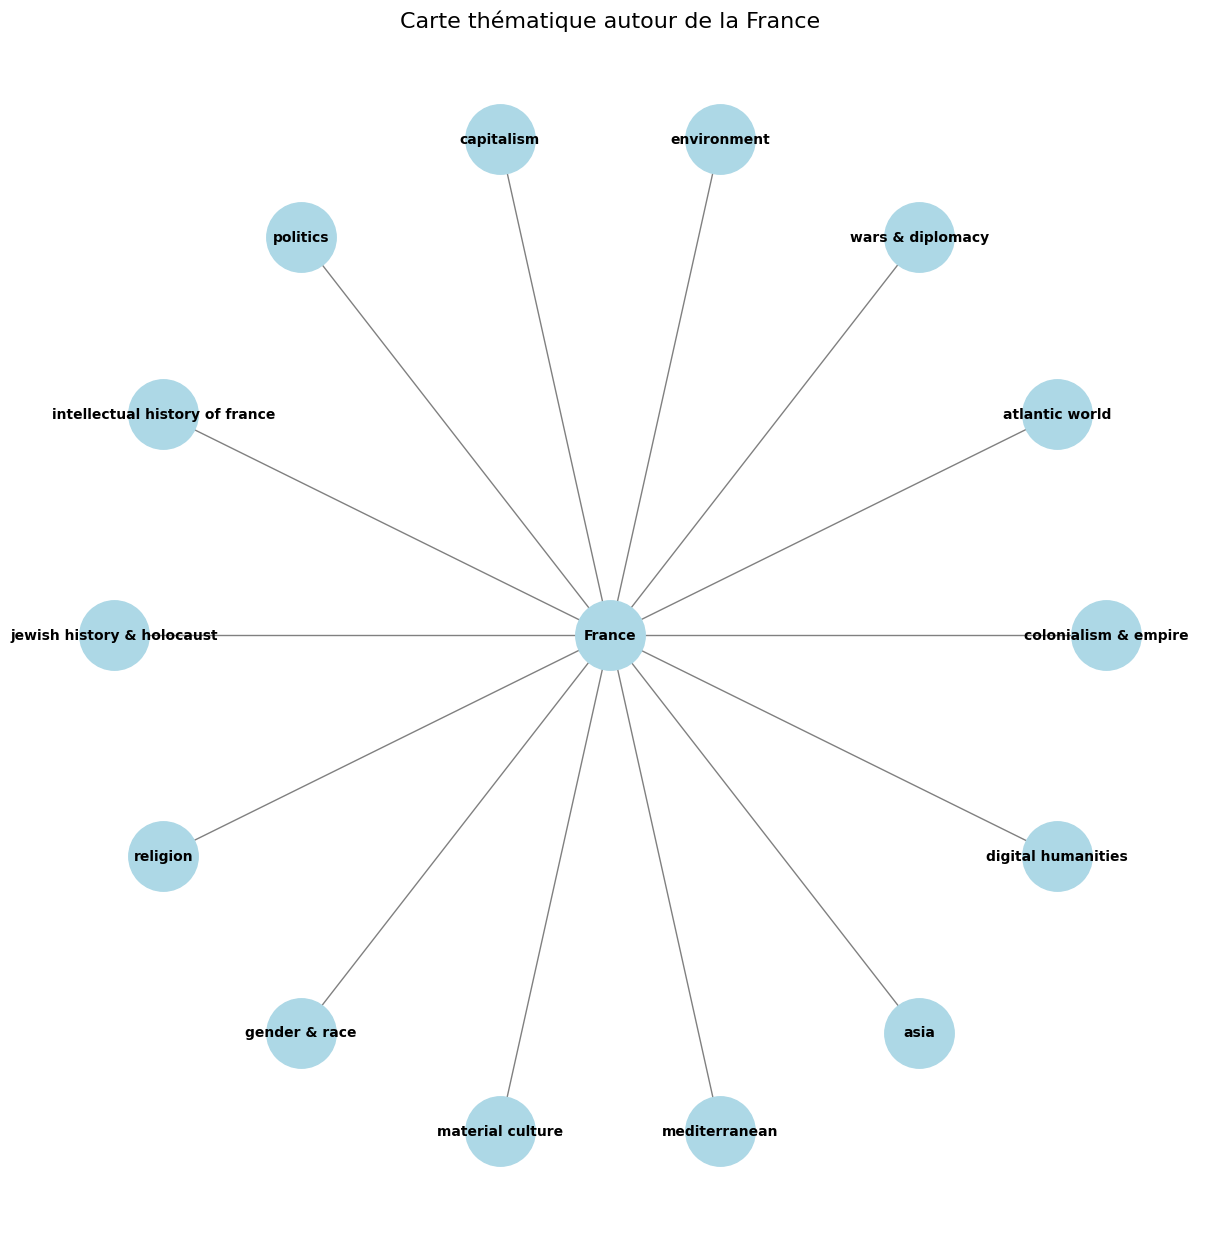

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt


# création du graphe
G = nx.Graph()

# noeud central
G.add_node("France")

# on ajoute les thèmes comme noeuds connectés
for t in themes:
    G.add_node(t)
    G.add_edge("France", t)

# positions circulaires
pos = {}
pos["France"] = (0,0)  # centre
circle_pos = nx.circular_layout([t for t in themes], scale=3)

# fusion des positions
pos.update(circle_pos)

plt.figure(figsize=(12,12))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=10,
    font_weight='bold',
    node_color='lightblue',
    edge_color='grey'
)

plt.title("Carte thématique autour de la France", fontsize=16)
plt.axis("off")
plt.show()